# Module 8: AI publications choropleth

This map shows the compound annual growth rate of scholarly AI publications by country from 2016 to 2024.

Publication data comes from the CSET Country AI Activity Metrics dataset, processed by Our World in Data. Country boundaries come from Natural Earth's 1:10 million Admin 0 dataset.

CAGR measures the average annual rate of change. Countries with a small number of publications in 2016 can record a high CAGR from a relatively small numerical increase.

## Step 1: Load and clean the data

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

df = pd.read_csv("annual-scholarly-publications-on-artificial-intelligence.csv")
df.columns = ["Entity", "Code", "Year", "n_pubs"]

# show every OWID region/aggregate code actually present in the raw data
owid_codes = df[df["Code"].str.startswith("OWID_", na=False)][["Entity", "Code"]].drop_duplicates()
print(owid_codes)

region_codes = ["OWID_AFR", "OWID_ASI", "OWID_EUR", "OWID_NAM", "OWID_OCE", "OWID_SAM", "OWID_WRL"]

# remove regional and world aggregates
countries = df[~df["Code"].isin(region_codes)]

#remove rows without a country code 
countries = countries[countries["Code"].notna()].copy()

print("Country entities:", countries["Entity"].nunique())

             Entity      Code
8            Africa  OWID_AFR
76             Asia  OWID_ASI
484          Europe  OWID_EUR
758          Kosovo  OWID_KOS
1055  North America  OWID_NAM
1100        Oceania  OWID_OCE
1334  South America  OWID_SAM
1577          World  OWID_WRL
Country entities: 190


## Step 2: Calculate CAGR from 2016 to 2024

In [2]:
start_year = 2016
end_year = 2024
years = end_year - start_year

data_2016 = countries[countries["Year"] == start_year][["Entity", "Code", "n_pubs"]]
data_2024 = countries[countries["Year"] == end_year][["Entity", "Code", "n_pubs"]]

# rename the publication columns
data_2016 = data_2016.rename(columns={"n_pubs": "pubs_2016"})
data_2024 = data_2024.rename(columns={"n_pubs": "pubs_2024"})

# start and end publication counts combine 
cagr = data_2016.merge(data_2024, on=["Entity", "Code"])
cagr["cagr"] = (cagr["pubs_2024"] / cagr["pubs_2016"]) ** (1 / years) - 1

print("Countries with both years:", len(cagr))

Countries with both years: 146


## Step 3: Load the country boundaries

In [3]:
map_url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_10m_admin_0_countries_lakes.geojson"

world = gpd.read_file(map_url)

# ADM0_A3 is used as the join key instead of ISO_A3 below
print("Features with missing ISO_A3:", (world["ISO_A3"] == "-99").sum())

world = world[["ADMIN", "ADM0_A3", "geometry"]]
world = world.rename(columns={"ADM0_A3": "iso3"})

print("Boundary features loaded:", len(world))

Features with missing ISO_A3: 22
Boundary features loaded: 258


## Step 4: Join the publication data to the map

In [4]:
# create the map join key and convert OWID's Kosovo code to the code used by Natural Earth
cagr["iso3"] = cagr["Code"].replace({"OWID_KOS": "KOS"})

# join the publication growth data to the country boundary data using the country code
merged = world.merge(cagr, on="iso3", how="left")

# remove Antarctica
merged = merged[merged["ADMIN"] != "Antarctica"].copy()

# project the map
merged = merged.to_crs("EPSG:8857")

print("Countries matched:", merged["cagr"].notna().sum())

Countries matched: 146


## Step 5: Create six equal-count CAGR groups

The class boundaries below are calculated directly from the CAGR values.

In [5]:
# divide countries with CAGR values into six groups
merged["cagr_class"], bin_edges = pd.qcut(merged["cagr"], 6, retbins=True, labels=False)

print("Calculated class boundaries:")
for edge in bin_edges:
    print(f"{edge:.1%}")

print(merged["cagr_class"].value_counts(dropna=False).sort_index())

Calculated class boundaries:
-8.3%
7.2%
11.4%
15.5%
23.0%
30.6%
77.0%
cagr_class
0.0     25
1.0     24
2.0     24
3.0     24
4.0     24
5.0     25
NaN    111
Name: count, dtype: int64


## Step 6: Draw the choropleth

The map colours and layout are design choices. The country values, six classes, class boundaries and colourbar values are calculated from the dataset.

Saved -> ai_cagr_choropleth.png


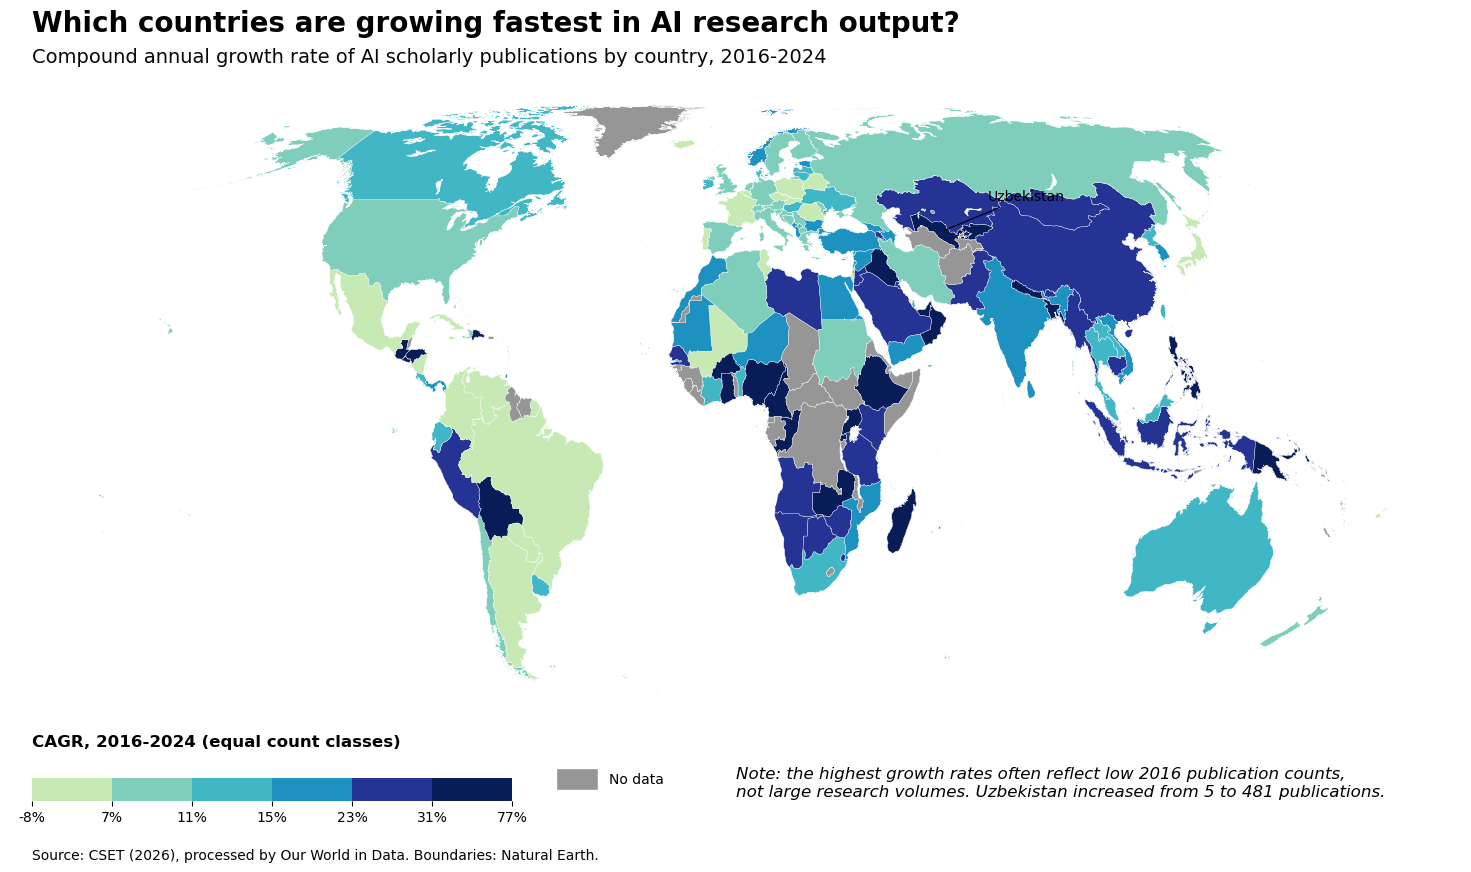

In [6]:
colors = ["#c7e9b4", "#7fcdbb", "#41b6c4", "#1d91c0", "#253494", "#081d58"]

no_data_color = "#969696"

# custom colour map 
cmap = ListedColormap(colors)

# connect the calculated class boundaries with six colours
norm = BoundaryNorm(bin_edges, cmap.N)

LEFT = 0.06

fig, ax = plt.subplots(figsize=(16, 9))

merged.plot(column="cagr", ax=ax, cmap=cmap, norm=norm, missing_kwds={"color": no_data_color}, edgecolor="white", linewidth=0.25)

ax.set_axis_off()

ax.set_position([0.0, 0.17, 1.0, 0.72])

fig.text(LEFT, 0.94, "Which countries are growing fastest in AI research output?", fontsize=20, fontweight="bold", ha="left")
fig.text(LEFT, 0.905, "Compound annual growth rate of AI scholarly publications by country, 2016-2024", fontsize=14, color="#080808", ha="left")

fig.text(LEFT, 0.145, "CAGR, 2016-2024 (equal count classes)", fontsize=12, fontweight="bold", ha="left")

cax = fig.add_axes([LEFT, 0.085, 0.30, 0.025])

# object used by matplotlib to connect CAGR values 
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

cb = fig.colorbar(sm, cax=cax, orientation="horizontal")

cb.set_ticks(bin_edges)

# class boundaries as percentages
cb.ax.set_xticklabels([f"{edge:.0%}" for edge in bin_edges], fontsize=10)

# outline remove
cb.outline.set_visible(False)

no_data_patch = Patch(facecolor=no_data_color, edgecolor="white", label="No data")
fig.legend(handles=[no_data_patch], loc="lower left", bbox_to_anchor=(0.38, 0.083), frameon=False, fontsize=10, handlelength=3, handleheight=2)
uzbekistan = merged[merged["ADMIN"] == "Uzbekistan"]

if not uzbekistan.empty:
    point = uzbekistan.geometry.representative_point().iloc[0]
    ax.annotate("Uzbekistan", xy=(point.x, point.y), xytext=(point.x + 1200000, point.y + 800000), arrowprops={"arrowstyle": "-", "linewidth": 0.8}, fontsize=10)

fig.text(0.50, 0.105, "Note: the highest growth rates often reflect low 2016 publication counts,\nnot large research volumes. Uzbekistan increased from 5 to 481 publications.", fontsize=12, color="#000000", style="italic", ha="left", va="center")
fig.text(LEFT, 0.02, "Source: CSET (2026), processed by Our World in Data. Boundaries: Natural Earth.", fontsize=10, color="#030303", ha="left")
fig.savefig("ai_cagr_choropleth.png", dpi=200, bbox_inches="tight", facecolor="white")

print("Saved -> ai_cagr_choropleth.png")
plt.show()
plt.close(fig)